# Exploratory Data Analysis

In [1]:
# Imports

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical functions
from scipy.stats import variation

# Math functions
import math

# Machine learning models
from sklearn.linear_model import LinearRegression

In [2]:
### JUST FOR ME, TO DELETE LATER ###
# Display all rows and columns in the DataFrame
# Comment if effect unwanted
# pd.set_option('display.max_rows', None)  # No limit on number of rows
# pd.set_option('display.max_columns', None)  # No limit on number of columns
# pd.set_option('display.width', None)  # Auto-adjust the width
# pd.set_option('display.max_colwidth', None)  # Show full content of each column

## Data Loading and Initial Inspection

In [3]:
# Load datasets: Data Matrix, Feature Metadata, Acquisition List, and Exogenous Standards
data_matrix = pd.read_csv("./data/input/internship_data_matrix.csv")
feature_metadata = pd.read_csv("./data/input/internship_feature_metadata.csv")
acquisition_list = pd.read_csv("./data/input/intership_acquisition_list.csv")
exogenous_stds = pd.read_csv("./data/input/exogenous_standards.csv")

# Preview datasets: display first rows and shape to understand structure
display(data_matrix.head(), data_matrix.shape)
display(feature_metadata.head(), feature_metadata.shape)
display(acquisition_list.head(), acquisition_list.shape)
display(exogenous_stds.head(), exogenous_stds.shape)


,sample,FT-000,FT-001,FT-002,FT-003,FT-004,FT-005,FT-006,FT-007,FT-008,...,FT-242,FT-243,FT-244,FT-245,FT-246,FT-247,FT-248,FT-249,FT-250,FT-251
0,20241106-297-Blank1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,20241106-297-Blank2,0.0,0.000000,0.0,5.770641,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.534493,0.0,0.0,0.0
2,20241106-297-Blank3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6.469501,0.0,0.0,0.0
3,20241106-297-Blank4,0.0,5.497865,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,20241106-297-Blank5,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


(124, 253)

,feature,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-000,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
1,FT-001,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
2,FT-002,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647
3,FT-003,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
4,FT-004,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684


(252, 11)

,sample,class,id,order,batch
0,20241106-297-Blank1,B,20241106-297-Blank1,1,1
1,20241106-297-Blank2,B,20241106-297-Blank2,2,1
2,20241106-297-Blank3,B,20241106-297-Blank3,3,1
3,20241106-297-Blank4,B,20241106-297-Blank4,102,1
4,20241106-297-Blank5,B,20241106-297-Blank5,103,1


(124, 5)

,compound_id,mz,Retention_time
0,GU4,886.40,610
1,GU5,1048.45,753
2,GU14,1253.96,1500
3,GU15,1334.99,1551


(4, 3)

Initial inspection of the data:
- Data Matrix (N, M): Contains peak areas of the different samples measured in the experiment. These are calculated as the integration of the chromatographic peaks curve in the time domain buond by peak start and end. This represents our quantitative measure, used to quantify presence of a molecule 
    - N = 124 samples, M = 253 features (252 features and one column for sample ID).
- Feature Metadata (M, K): Describes each chromatographic feature, including properties such as mass-to-charge ratio (mean, max, min, std) and retention time (mean, start, end, max, min, std) 
    - M = 252 features, K = 11 descriptors.
- Acquisition List (N, D): Provides metadata for each sample, such as batch number and run order
    - N = 124 samples, D = 5 descriptors.
- Exogenous Standards (S, k): Metadata for known external standards, with descriptors for each feature 
    - S = 4 features, k = 2 descriptors.

In [ ]:
# Set index columns to ensure consistent sample/feature alignment across datasets
data_matrix = data_matrix.set_index('sample')               # Use 'sample' as index for data matrix
feature_metadata = feature_metadata.set_index('feature')    # Use 'feature' as index for feature metadata
acquisition_list = acquisition_list.set_index('sample')     # Use 'sample' as index for acquisition list
exogenous_stds = exogenous_stds.set_index('compound_id')    # Use 'compound_id' as index for exogenous standards

In [12]:
# Check for missing values in our data
print("Missing values in Data Matrix:", data_matrix.isnull().values.any())
print("Missing values in Feature Metadata:", feature_metadata.isnull().values.any())

# Check for negative values in our data
print("Negative values in Data Matrix:", (data_matrix < 0).values.any())
print("Neagtive values in Feature Metadata:", (feature_metadata < 0).values.any())

Missing values in Data Matrix: False
Missing values in Feature Metadata: False
Negative values in Data Matrix: False
Neagtive values in Feature Metadata: False


In [14]:
# Merge Acquisition List with Data Matrix to include sample metadata (e.g., class, batch, run order)
data_matrix_types = data_matrix.join(other=acquisition_list)

# Normalize class labels: treat 'dQC' as 'QC' for consistency in downstream analysis
data_matrix_types['class'] = data_matrix_types['class'].replace('dQC', 'QC')

# Verify unique sample classes after replacement
print(data_matrix_types['class'].unique())

['B' 'QC' 'Dunn' 'SS' 'French' 'LMU']


All datasets have been successfully loaded, aligned, and checked for preliminary inspections.

The data is now ready for exploratory analysis and visualization.

## Basic Data Exploration

Here, we perform several visual analyses to understand the structure and distribution of the dataset:

- Plotted the **distribution of a few sample intensities** to inspect overall signal levels across features.
- Generated **histograms for retention time and mass-to-charge ratio (m/z)** across all samples to evaluate their global distributions and identify potential outliers or skew.
- Visualized the **number of samples per batch** to assess the balance and structure of the experimental design.
- Created **barplots of retention time and m/z for exogenous standards** to examine their spread and consistency as reference points.

These steps help verify data quality, highlight possible anomalies, and provide a foundation for further preprocessing and analysis.

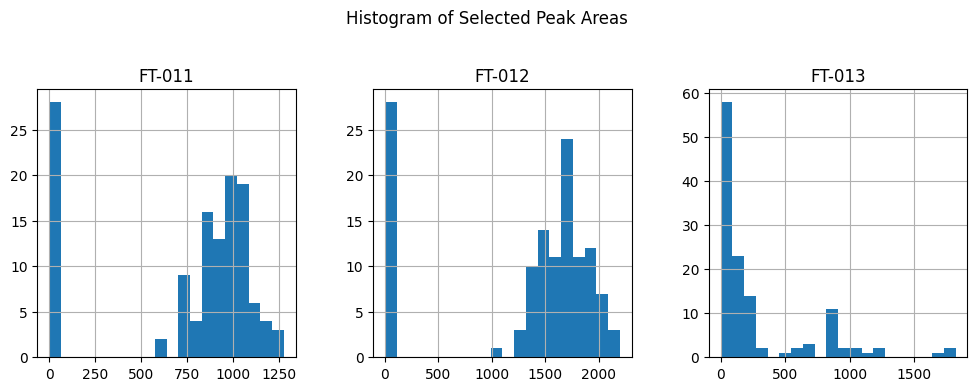

In [24]:
# Distribution of a few sample intensities
sample_features = data_matrix.columns[11:14]  # just explore some features for illustration
data_matrix[sample_features].hist(bins=20, figsize=(12, 8), layout=(2, 3))
plt.suptitle("Histogram of Selected Peak Areas")
plt.show()

In [ ]:
# Checking classes of samples
print(data_matrix_types['class'].unique())

['B' 'QC' 'Dunn' 'SS' 'French' 'LMU']


The classes of samples we are dealing with are:
- B: Blank samples. No biological information, used to assess contaminants.
- QC: Quality Checks. Mixture of all samples to monitor signal consistency. 
- Dunn: Healthy subjects samples.
- LMU: Benign Disease subjects samples.
- French: Lung Cancer subjects samples.
- SS: Contains Exogenous Standards for monitoring detector behavior.

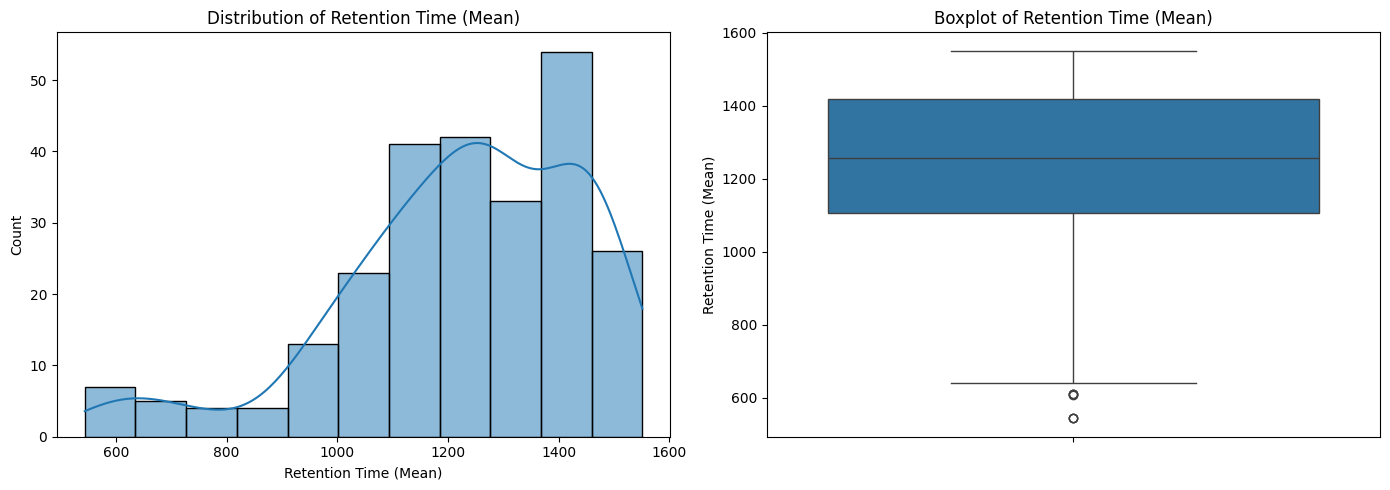

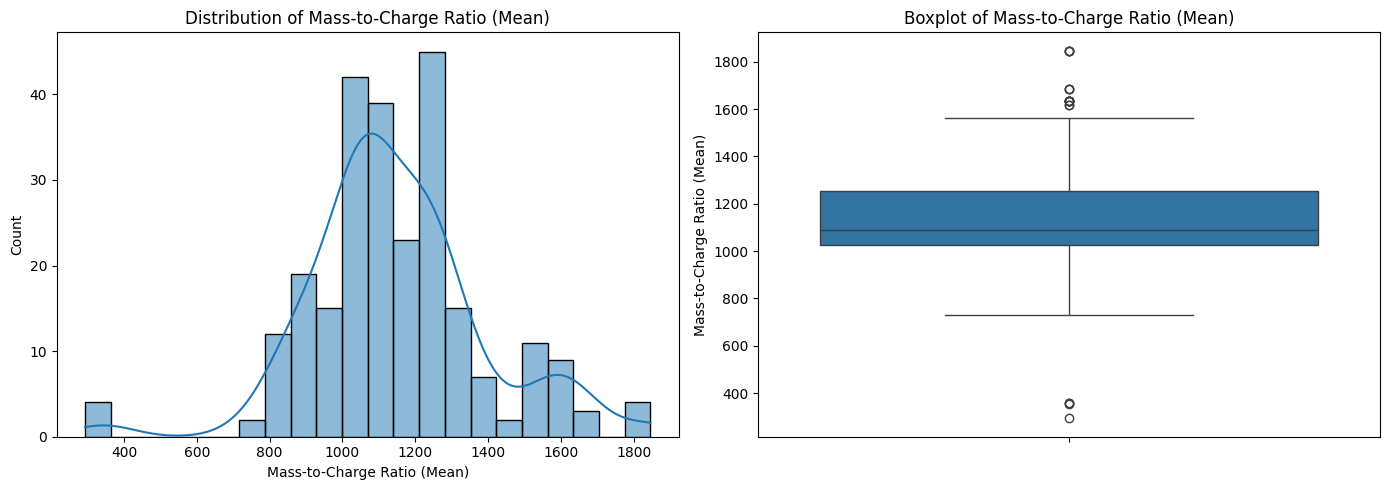

In [ ]:
# Generate a histogram with KDE and a boxplot for retention time and mass-to-charge ratio of all samples
for descriptor in ['rt', 'mz']:
    
    # Set appropriate title based on descriptor
    if descriptor == 'rt':
        title = 'Retention Time'
    else:
        title = 'Mass-to-Charge Ratio'
    
    # Create a figure with 2 subplots side by side
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram with KDE for the descriptor
    sns.histplot(feature_metadata[descriptor], kde=True, ax=axs[0])
    axs[0].set_title(f"Distribution of {title} (Mean)")
    axs[0].set_xlabel(f"{title} (Mean)")

    # Boxplot for the same descriptor
    sns.boxplot(y=feature_metadata[descriptor], ax=axs[1])
    axs[1].set_title(f"Boxplot of {title} (Mean)")
    axs[1].set_ylabel(f"{title} (Mean)")

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

- The histogram of retention time is **slightly right-skewed**, with a concentration of features of retention time between ~1000 and 1500 units (seconds or minutes, unclear to me). 
- The corresponding **boxplot** confirms this, showing a few low-end outliers below 700.
This suggests that most metabolites elute later in the chromatographic run.

- The histogram of m/z appears more **normally distributed**, centered around 1100–1200, but with some high-end and low-end outliers.
- The boxplot of m/z (bottom right) highlights these outliers clearly, especially a few above 1700 and below 500.
The tighter m/z distribution indicates that most detected metabolites fall within a narrow mass range. Outliers at both ends may represent unusual metabolites or noise.

Together, these patterns reflect the chemical diversity of the sample

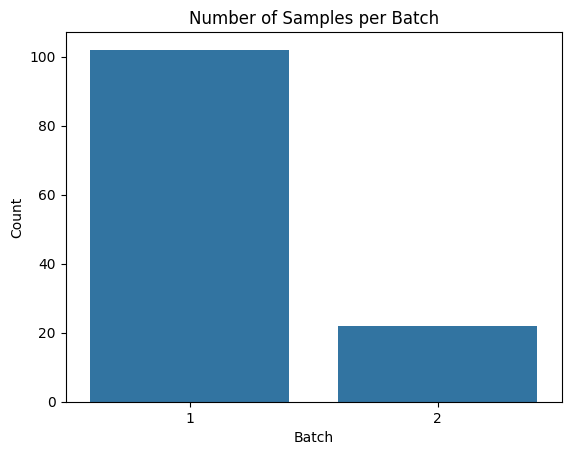

In [39]:
# Plot the number of samples per batch
plt.figure()
sns.countplot(x='batch', data=acquisition_list)
plt.title("Number of Samples per Batch")
plt.xlabel("Batch")
plt.ylabel("Count")
plt.show()

Batch 1 contains the majority of samples (~100), while batch 2 contains significantly fewer samples (~20). This is due to the fact that batch 2 actually dos not contain any sample data.

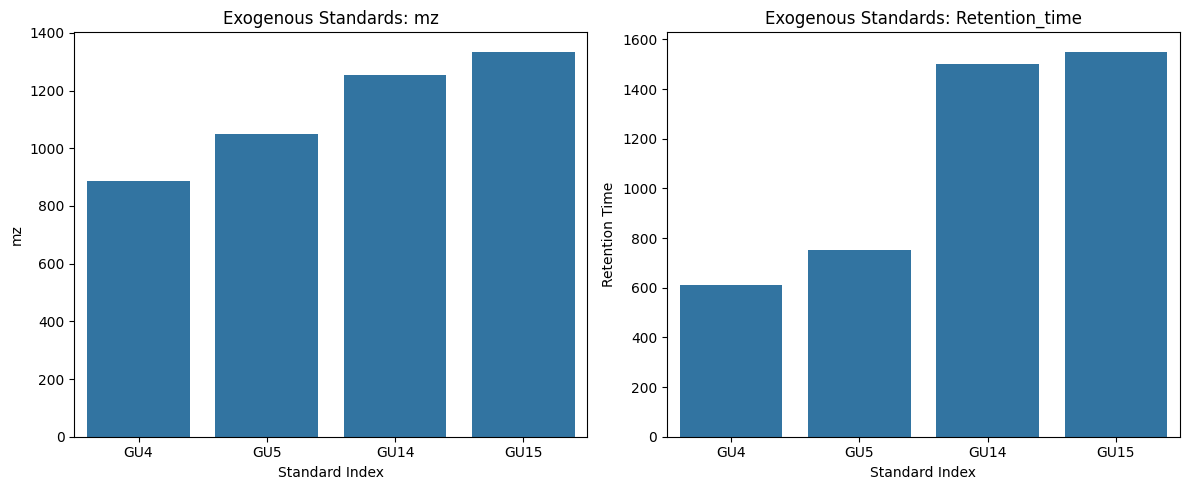

In [ ]:
# Plot the mean retention time and mass-to-charge ratio for each Exogenous Standard
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot barplot for 'mz' values of exogenous standards
sns.barplot(x=exogenous_stds.index, y=exogenous_stds['mz'], ax=axs[0])
axs[0].set_title("Exogenous Standards: mz")
axs[0].set_xlabel("Standard Index")
axs[0].set_ylabel("mz")

# Plot barplot for 'Retention_time' values of exogenous standards
sns.barplot(x=exogenous_stds.index, y=exogenous_stds['Retention_time'], ax=axs[1])
axs[1].set_title("Exogenous Standards: Retention_time")
axs[1].set_xlabel("Standard Index")
axs[1].set_ylabel("Retention Time")

plt.tight_layout()
plt.show()N

These bar plots show the **mass-to-charge ratio (m/z)** and **retention time** of four **exogenous standards** (GU4, GU5, GU14, GU15), which are glycan units, e.g. GU4 is composed of four glycan units from a Maltodextrin ladder.

Both **m/z** and **retention time** increase consistently with the GU index.

## Quantitative Quality Criteria

In this section, we assess the consistency and reliability of the data using two key quantitative metrics:

- **Coefficient of Variation (CV):** Computed for each feature within different sample groups (QC, lung cancer, healthy, benign disease) to measure the variability of peak areas relative to their mean. Lower CVs indicate higher consistency within a group.

- **Dispersion Ratio:** Calculated as the ratio of the median CV in QC samples to the median CV in biological samples. This metric helps evaluate whether technical variability (QC) is significantly lower than biological variability, as expected in well-controlled experiments.

### 1. Coefficient of Variation (CV)

The **coefficient of variation (CV)** is an important metric used to measure the **variability** of a set of values relative to the mean. It is particularly useful in assessing **technical variability** in experiments like LC-MS, where consistent measurement is crucial. CV is calculated as:

<img src="./images/CV.png" alt="Alt Text" width="300"/>

In peak area data from LC-MS experiments, **CV** allows to quantify the variability across replicate measurements of the same sample, helping evaluate the precision of the analytical method.

This information is provided in this [paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC3695475/).

In [67]:
# Define a function to compute and visualize the Coefficient of Variation (CV) for a given sample class
# We should look at one batch at a time
def cv(data_matrix, data_matrix_types, class_name, batch, visualize=False):
    data = data_matrix.copy()
    
    # Select only the samples measured in a specific batch
    data = data_matrix[(data_matrix_types['batch'] == batch)]
    
    # Select only the samples corresponding to the specified class
    data = data[(data_matrix_types['class'] == class_name)]
    
    # Calculate CV (%) for each feature: (standard deviation / mean) * 100
    cv = data.std() / data.mean() * 100
    
    if visualize==True:
        # Plot a histogram of CV values across all features
        plt.figure(figsize=(10, 6))
        plt.hist(cv, bins=30, edgecolor='black')
        plt.title(f"Distribution of Coefficient of Variation (CV) Across Features for class: {class_name} (Batch {batch})")
        plt.xlabel("CV (%)")
        plt.ylabel("Number of Features")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    # Return the computed CV values
    return cv

/var/folders/f6/p2jq7zvd7jq9y5mvqb6p1wlh0000gn/T/ipykernel_17963/1293963619.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = data[(data_matrix_types['class'] == class_name)]


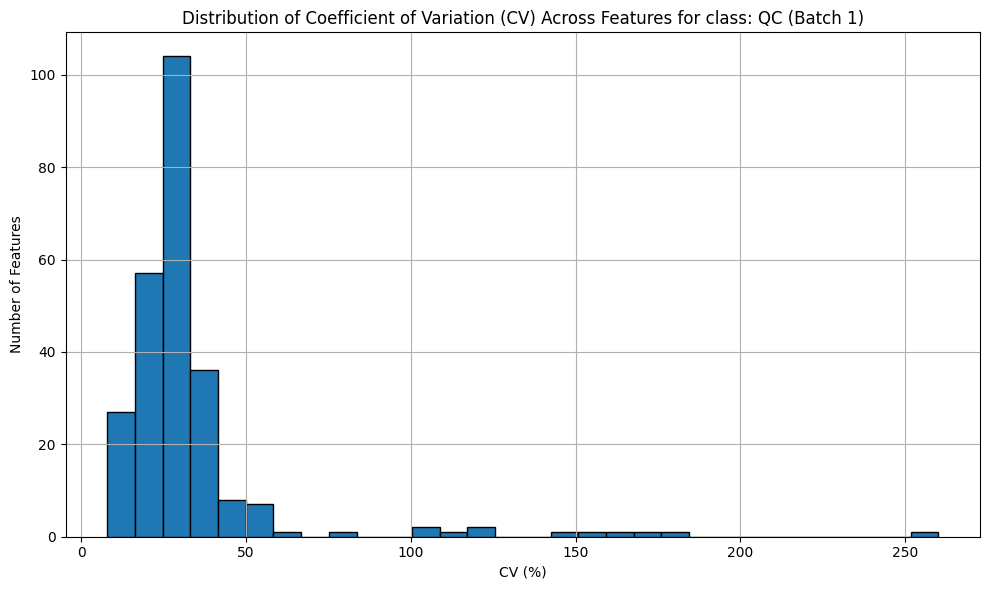

/var/folders/f6/p2jq7zvd7jq9y5mvqb6p1wlh0000gn/T/ipykernel_17963/1293963619.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = data[(data_matrix_types['class'] == class_name)]


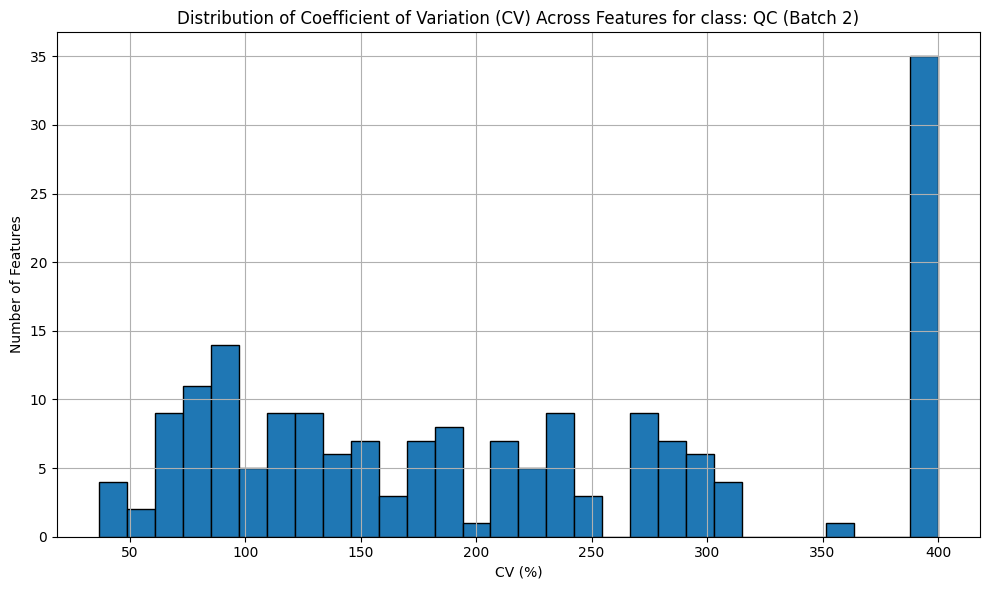

In [68]:
cv_qc_1 = cv(data_matrix, data_matrix_types, 'QC', batch=1, visualize=True)
cv_qc_2 = cv(data_matrix, data_matrix_types, 'QC', batch=2, visualize=True)

- QC (Batch 1) shows a tight CV distribution, with most features below 30%, indicating high technical reproducibility, as expected.

- QC (Batch 2) displays a highly dispersed CV profile, with many features above 100%. This is probably due to the fact that batch 2 does not contain any sample data.

## 2. Dispersion Ratio (D-Ratio)

The D-ratio represents the relation of the statistical dispersion of the QCs to the dispersion of the biological test samples. The D-ratio is calculated by dividing the technical variation by the total observed variation; this is the sum of technical and biological variation. Here, the variance of the QCs (𝜎2𝑖,𝑄⁢𝐶) approximates the technical variation, and the variance of the biological test samples (𝜎2𝑖,𝑠⁢𝑎⁢𝑚⁢𝑝⁢𝑙⁢𝑒) approximates the overall biological variation.

<img src="./images/D_ratio.png" alt="Alt Text" width="300"/>

A D-ratio close to 0% would be a perfect measurement, where the technical variance is zero and all observed variance originates from the biological variation. On the other hand, a D-ratio of 100% would be the worst possible measurement, where there is no biological variation and only noise is detected. A metabolite, where 𝜎2𝑖,𝑠⁢𝑎⁢𝑚⁢𝑝⁢𝑙⁢𝑒 ≫ 𝜎2𝑖,𝑄⁢𝐶 with a D-ratio below 50%, is preferred.

This information was provided in this [paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC10222478/).

/var/folders/f6/p2jq7zvd7jq9y5mvqb6p1wlh0000gn/T/ipykernel_17963/1293963619.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = data[(data_matrix_types['class'] == class_name)]
/var/folders/f6/p2jq7zvd7jq9y5mvqb6p1wlh0000gn/T/ipykernel_17963/1293963619.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = data[(data_matrix_types['class'] == class_name)]
/var/folders/f6/p2jq7zvd7jq9y5mvqb6p1wlh0000gn/T/ipykernel_17963/1293963619.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = data[(data_matrix_types['class'] == class_name)]


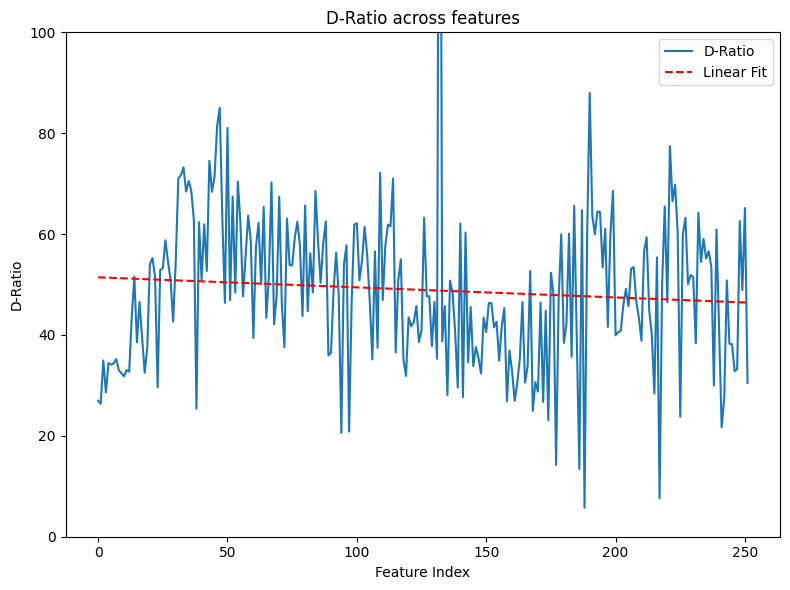

In [89]:
cv_LMU = cv(data_matrix, data_matrix_types, 'LMU', batch=1, visualize=False)
cv_french = cv(data_matrix, data_matrix_types, 'French', batch=1, visualize=False)
cv_dunn = cv(data_matrix, data_matrix_types, 'Dunn', batch=1, visualize=False)

# Compute D-Ratio
d_ratio = cv_qc_1 / (cv_LMU + cv_dunn + cv_french) * 100

# Prepare x (feature index) and y (d_ratio)
x = np.arange(len(d_ratio))
y = d_ratio.values

# Fit a linear regression line
slope, intercept = np.polyfit(x, y, 1)
line = slope * x + intercept

# Plot
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='D-Ratio')
plt.plot(x, line, color='red', linestyle='--', label='Linear Fit')
plt.title('D-Ratio across features')
plt.xlabel('Feature Index')
plt.ylabel('D-Ratio')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


This plot shows the **D-Ratio** (QC variability over biological variability) for each feature.

- Most features have D-Ratios between **30% and 70%**, suggesting that **biological variance exceeds technical variance**, which is desirable in metabolomics data.
- The **regression line is slightly negative**, indicating a **mild downward trend** in D-Ratio across features — i.e., **technical variability becomes slightly less dominant** for later features. It also shows that on average, the d-ratio is of around 50%.
- A few spikes and drops (e.g., features with D-Ratio near **0%** or **100%**) may reflect **unstable or low-intensity signals**, and might be flagged for removal or further inspection.

In line with Gonzalez et al. (2013), features with D-Ratio < 50% are preferred, as they suggest that **biological signal dominates** over noise — making them more robust for downstream modeling.

## Identification of Potential Isomers, Isotopes, and Adducts

### 1. Isomers

In this part, we will visualize mass to charge ratios to identify isomers, i.e. molecules that have the same mass but different retention times.

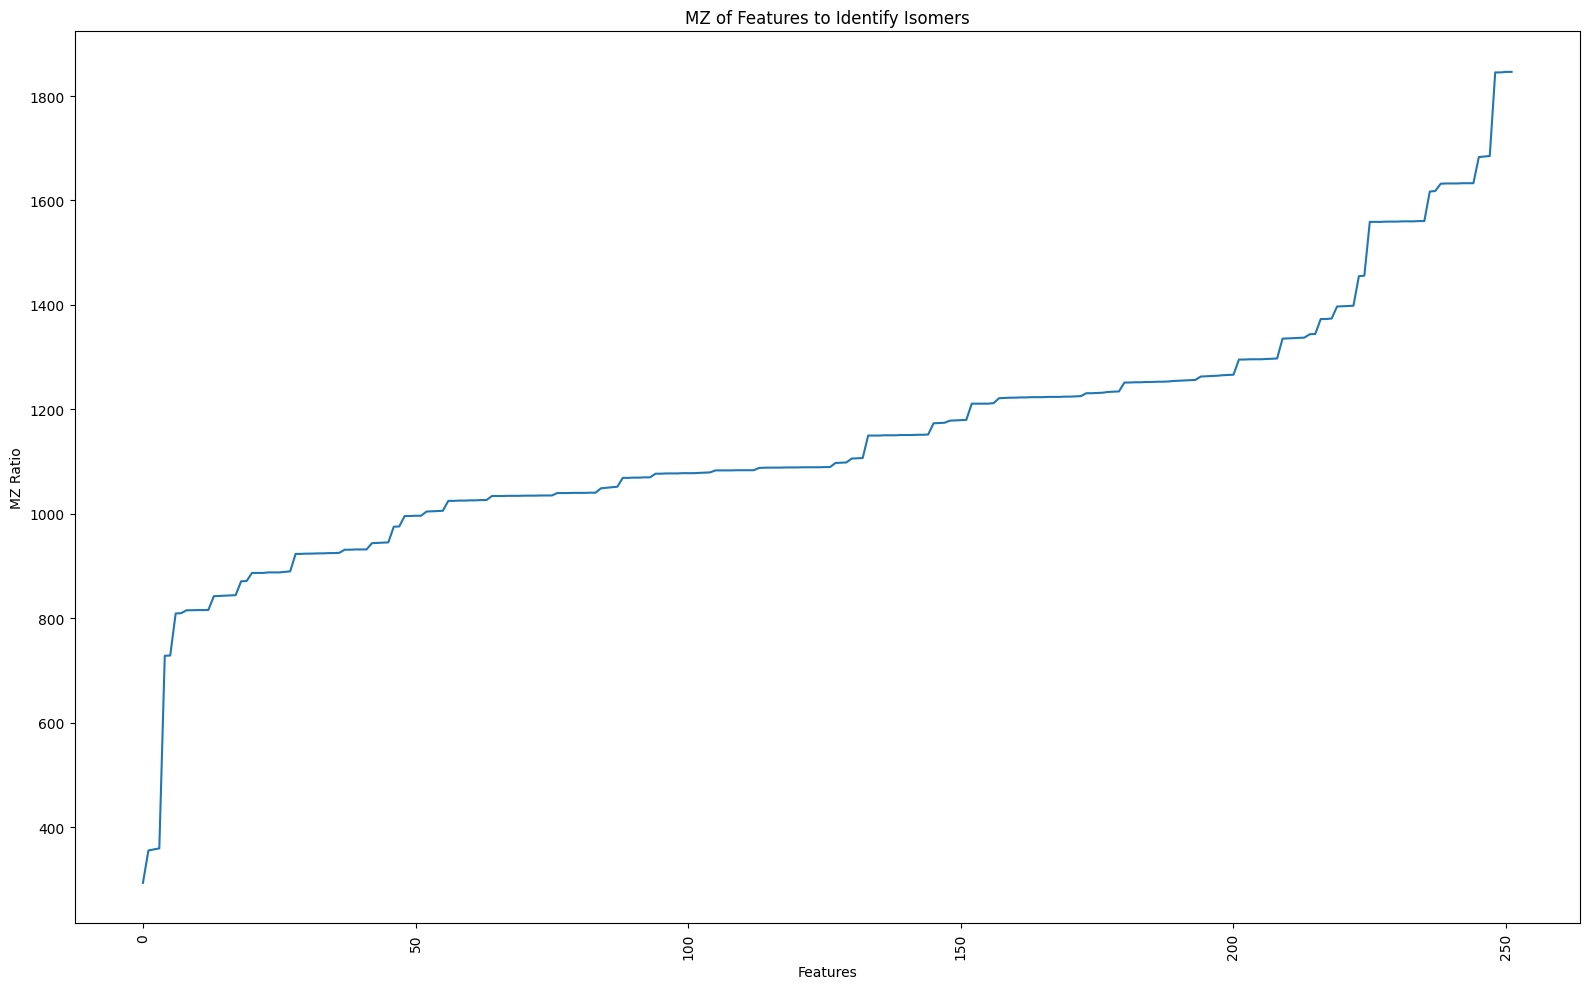

In [90]:
# Extract the mass-to-charge (m/z) values from the feature metadata
mz = feature_metadata['mz']

# Sort the m/z values in ascending order to facilitate comparison and isomer detection
mz = mz.sort_values(ascending=True)

# Plot the sorted m/z values as a line plot to identify potential isomers (features with similar m/z)
mz.reset_index(drop=True).plot(kind='line', figsize=(16, 10))
plt.xlabel("Features")  
plt.ylabel("MZ Ratio")  
plt.title("MZ of Features to Identify Isomers")     
plt.xticks(rotation=90)     # Rotate x-axis labels for better readability
plt.tight_layout()          # Adjust layout to prevent clipping
plt.show()

- Many features have **very similar m/z values**, potentially indicating **isomers**.
- The **steep rises** may reflect transitions to **distinct compound classes** with different molecular weights.
- The **densely packed regions** (where m/z increases slowly) are especially interesting, as they likely contain **isomeric clusters** that may need to be resolved based on **retention time or fragmentation patterns**.

This kind of visualization is useful for identifying **redundant or structurally related features** that may require further investigation, grouping, or annotation.

# STOPPED HERE

In [91]:
# Identify Isomers

tolerance = 5  
isomer_labels = {}  # To store labels
visited = set()
isomer_id = 1

for index_i, mz_i in feature_metadata.mz.items():
    if index_i in visited:
        continue
    
    # Find all isomers within tolerance
    group = []
    for index_j, mz_j in feature_metadata.mz.items():
        if abs(mz_j - mz_i) <= tolerance:
            group.append(index_j)
    
    # Label all in the group
    for idx in group:
        isomer_labels[idx] = f"Isomer{isomer_id}"
        visited.add(idx)
    
    isomer_id += 1

# Add to dataframe
feature_metadata['Isomer'] = feature_metadata.index.map(isomer_labels)

In [92]:
# Prepare: get mapping from feature to isomer group
feature_to_isomer = feature_metadata['Isomer'].dropna()

# Initialize dictionary to store correlations per isomer group
isomer_correlations = {}

# For each isomer group
for isomer_group, features in feature_to_isomer.groupby(feature_to_isomer).groups.items():
    # Subset the data_matrix for the features in this isomer group
    isomer_data = data_matrix[features]
    
    # Only compute correlation if more than 1 feature in group
    if isomer_data.shape[1] > 1:
        # Compute the correlation matrix between features
        corr_matrix = isomer_data.corr()
        isomer_correlations[isomer_group] = corr_matrix


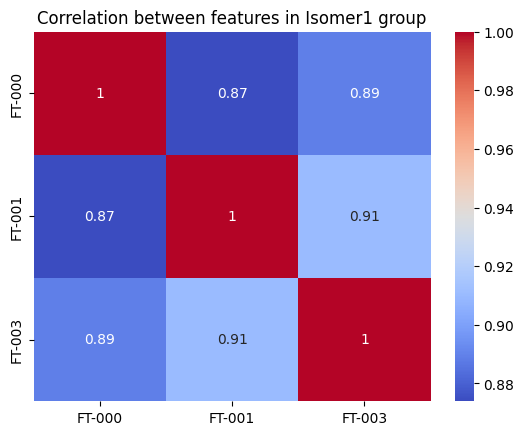

In [93]:
# Visualize the correlation between isomers, for example Isomer1
sns.heatmap(isomer_correlations['Isomer1'], annot=True, cmap='coolwarm')
plt.title('Correlation between features in Isomer1 group')
plt.show()

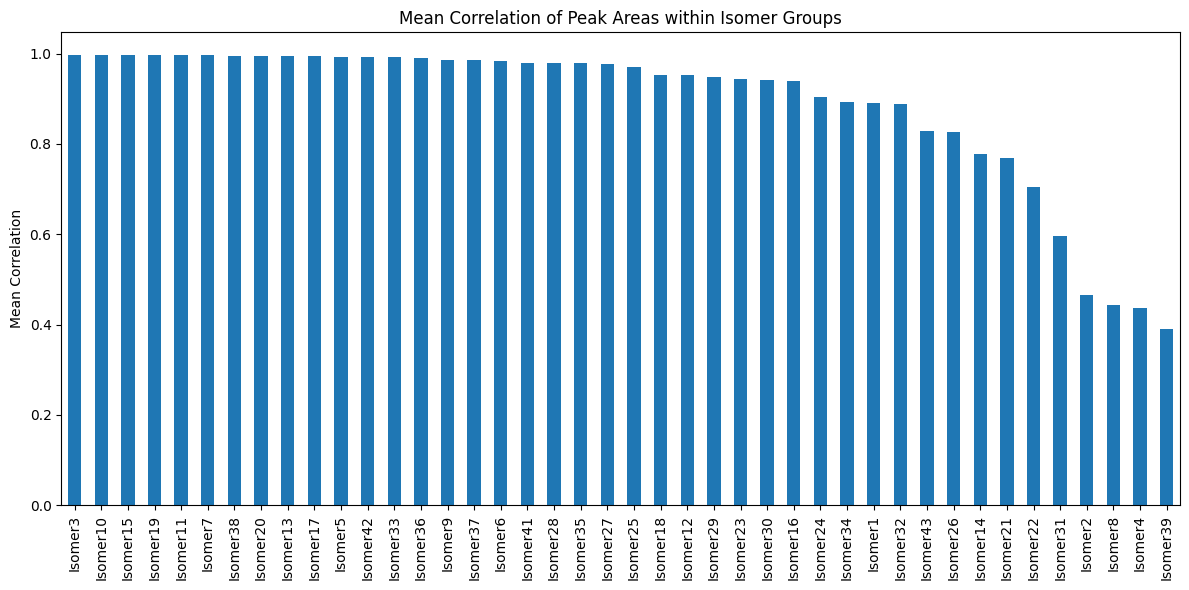

In [94]:
# Compute the mean correlation in each isomer group
mean_correlations = {}

for isomer_name, corr_matrix in isomer_correlations.items():
    if corr_matrix.shape[0] > 1:  # Only meaningful if there's more than one feature
        # Extract the lower triangle without the diagonal
        mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
        values = corr_matrix.values[mask]
        mean_corr = np.nanmean(values)  # nanmean in case of NaNs
        mean_correlations[isomer_name] = mean_corr

# Visualize mean correlation in each isomer group
mean_corr_series = pd.Series(mean_correlations).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
mean_corr_series.plot(kind='bar')
plt.ylabel('Mean Correlation')
plt.title('Mean Correlation of Peak Areas within Isomer Groups')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2. Isotopes (or Adducts)

In this part, we visualize the retention time of features, to identify isotopes, i.e. molecules that have same retention time but different mass.

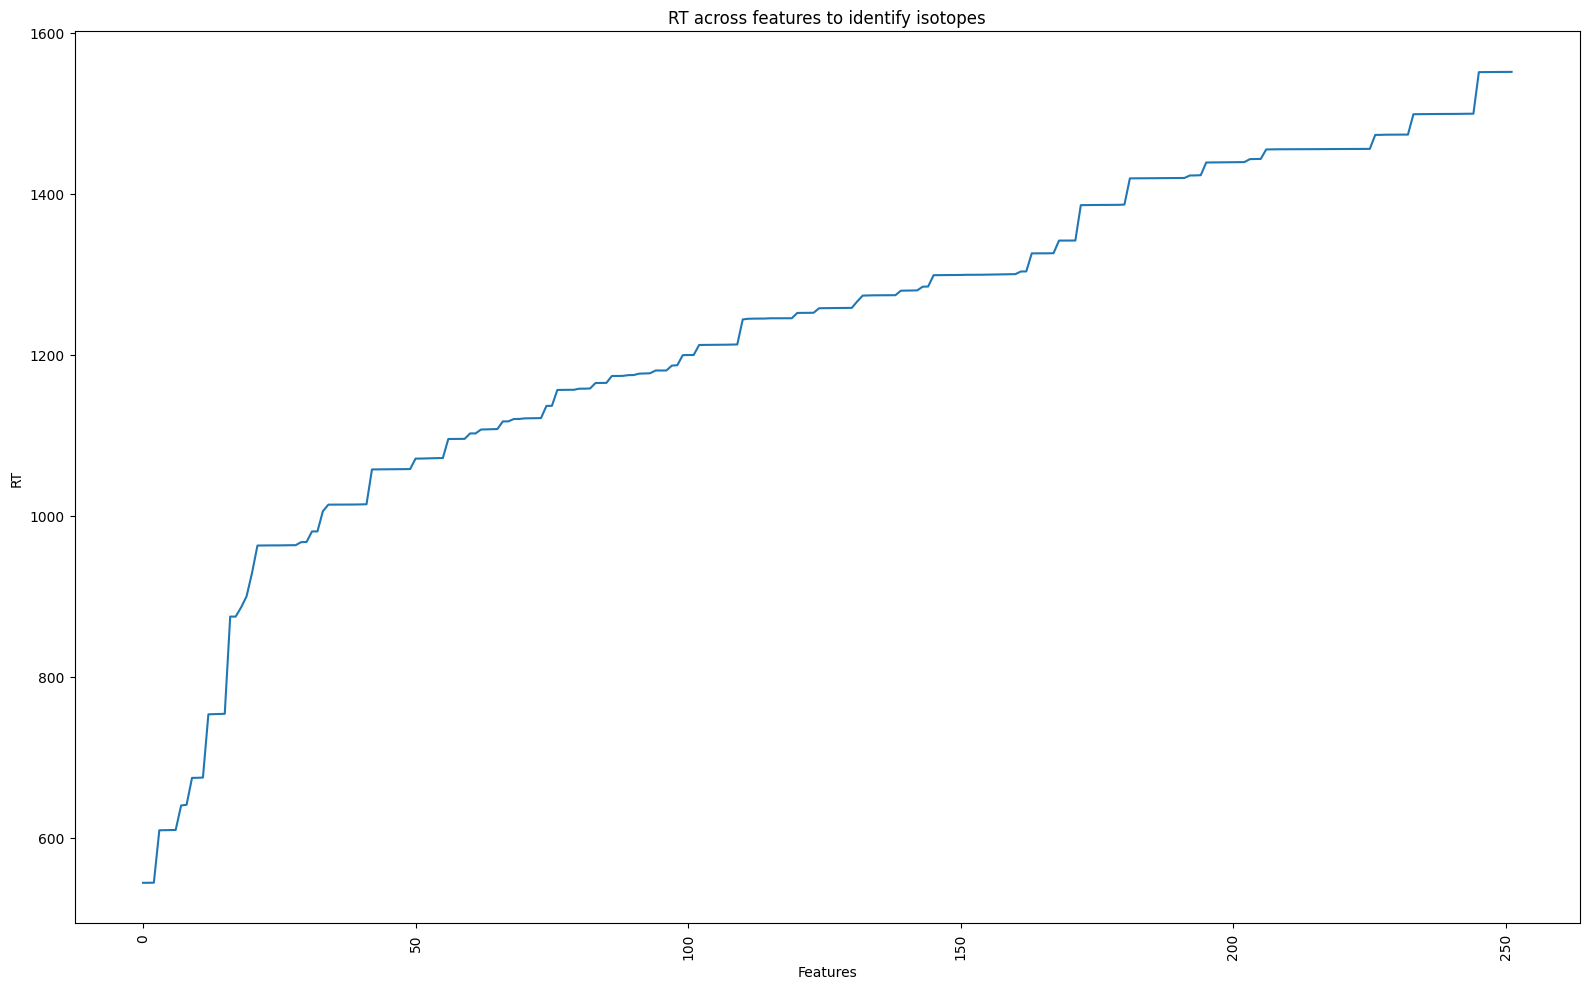

In [95]:
# Sort the dataframe for RT
rt = feature_metadata['rt']

# Sort from low to high for easier comparison
rt = rt.sort_values(ascending=True)

rt.reset_index(drop=True).plot(kind='line', figsize=(16, 10))
plt.xlabel("Features")  
plt.ylabel("RT")  
plt.title("RT across features to identify isotopes")     
plt.xticks(rotation=90)     
plt.tight_layout()          
plt.show()

As we can see, some features share similar retention times, indicating that some metabolites are isotopes.

Now, let us group isotopes together, such that we can investigate if there is any correlation in terms of peak areas between isotopes.

In [96]:
# Identify Isotopes

tolerance = 5  
isotope_labels = {}  # To store labels
visited = set()
isotope_id = 1

for index_i, rt_i in feature_metadata.rt.items():
    if index_i in visited:
        continue
    
    # Find all isotopes within tolerance
    group = []
    for index_j, rt_j in feature_metadata.rt.items():
        if abs(rt_j - rt_i) <= tolerance:
            group.append(index_j)
    
    # Label all in the group
    for idx in group:
        isotope_labels[idx] = f"Isotope{isotope_id}"
        visited.add(idx)
    
    isotope_id += 1

# Add to dataframe
feature_metadata['Isotope'] = feature_metadata.index.map(isotope_labels)

In [97]:
# Prepare: get mapping from feature to isotope group
feature_to_isotope = feature_metadata['Isotope'].dropna()

# Initialize dictionary to store correlations per isotope group
isotope_correlations = {}

# For each isotope group
for isotope_group, features in feature_to_isotope.groupby(feature_to_isotope).groups.items():
    # Subset the data_matrix for the features in this isotope group
    isotope_data = data_matrix[features]
    
    # Only compute correlation if more than 1 feature in group
    if isotope_data.shape[1] > 1:
        # Compute the correlation matrix between features
        corr_matrix = isotope_data.corr()
        isotope_correlations[isotope_group] = corr_matrix

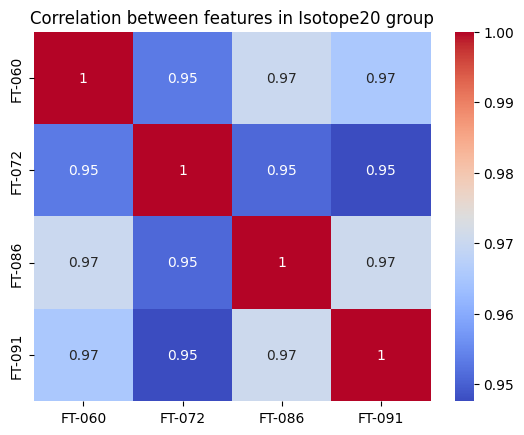

In [98]:
# Visualize the correlation between isotopes, for example Isotope
sns.heatmap(isotope_correlations['Isotope20'], annot=True, cmap='coolwarm')
plt.title('Correlation between features in Isotope20 group')
plt.show()

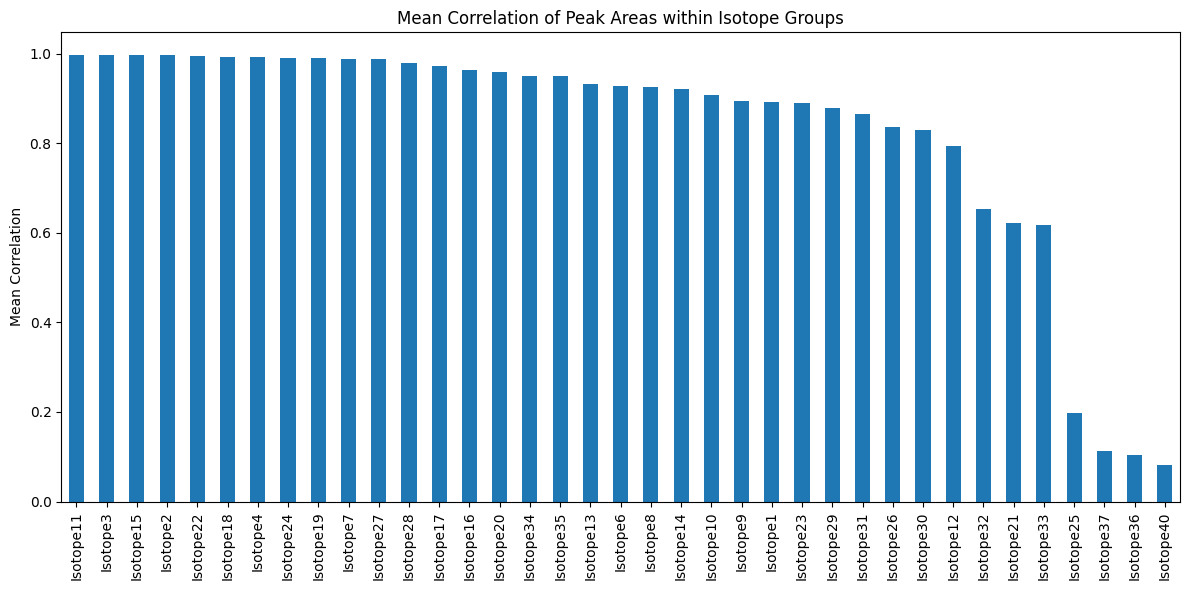

In [99]:
# Compute the mean correlation in each isotope group
mean_correlations = {}

for isotope_name, corr_matrix in isotope_correlations.items():
    if corr_matrix.shape[0] > 1:  # Only meaningful if there's more than one feature
        # Extract the lower triangle without the diagonal
        mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
        values = corr_matrix.values[mask]
        mean_corr = np.nanmean(values)  # nanmean in case of NaNs
        mean_correlations[isotope_name] = mean_corr

# Visualize mean correlation in each isotope group
mean_corr_series = pd.Series(mean_correlations).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
mean_corr_series.plot(kind='bar')
plt.ylabel('Mean Correlation')
plt.title('Mean Correlation of Peak Areas within Isotope Groups')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Feature Detection

### Detected Features

In this part, we will investigate how many features have been detected. For that purpose, we will define a threshold of minimal intensity to consider a peak detected. Let us start the investigation by looking at all peak area values of blank samples.

In [100]:
blanks = data_matrix[data_matrix_types['class'] == 'B']

for col in blanks.columns:
    unique_vals = blanks[col].unique()
    print(f"Column '{col}' has {len(unique_vals)} unique value(s): {unique_vals[:5]}")

Column 'FT-000' has 5 unique value(s): [ 0.         33.61631628  3.12611119 30.77433905 31.63486584]
Column 'FT-001' has 6 unique value(s): [  0.           5.49786469  46.54788477 174.31810378 176.86708684]
Column 'FT-002' has 1 unique value(s): [0.]
Column 'FT-003' has 5 unique value(s): [  0.           5.77064079  38.69531734 300.3181719  281.82681333]
Column 'FT-004' has 1 unique value(s): [0.]
Column 'FT-005' has 1 unique value(s): [0.]
Column 'FT-006' has 1 unique value(s): [0.]
Column 'FT-007' has 1 unique value(s): [0.]
Column 'FT-008' has 1 unique value(s): [0.]
Column 'FT-009' has 1 unique value(s): [0.]
Column 'FT-010' has 1 unique value(s): [0.]
Column 'FT-011' has 1 unique value(s): [0.]
Column 'FT-012' has 1 unique value(s): [0.]
Column 'FT-013' has 1 unique value(s): [0.]
Column 'FT-014' has 1 unique value(s): [0.]
Column 'FT-015' has 1 unique value(s): [0.]
Column 'FT-016' has 1 unique value(s): [0.]
Column 'FT-017' has 1 unique value(s): [0.]
Column 'FT-018' has 1 uniqu

As can be observed, most peak area values are 0, but some of them are higher. We will consider two different thresholds:
- The first is based on the observation of peak area values in blank samples. By looking at the unique values, it seems like many features have peak area values between 0 and 10. We will therefore consider a threshold for feature detection of 10.
- The second is based on Signal-to-Noise ratio (S/N). We can compute S/N for each feature, and consider features detected if their S/N is over 3, which is a technique widely used in literature.

In [101]:
# Manual Threshold
#threshold = 10 #comment if needed

# S/N Threshold
def sn_ratio(blanks, non_blanks):
    noise_std = blanks.std()
    signal_mean = non_blank_samples.mean()
    return signal_mean/noise_std

non_blank_samples = data_matrix.copy()
non_blank_samples = non_blank_samples[data_matrix_types['class'] != 'B']

#threshold = sn_ratio(blanks, non_blank_samples) #comment if needed

# Blank Sample-based Threshold
threshold = (blanks.mean() + 3*blanks.std()).mean() #comment if needed

# Count how many features have at least one value above the threshold
print("Total number of features detected across all samples:", (data_matrix > threshold).any(axis=0).sum())

# Are there any samples that do not have any features detected (excluding blank samples)?
print("Any non-blank samples with no features?:", ((non_blank_samples > threshold).sum(axis=1)==0).any())

# How many features in total have been detected?
print("Total number of features detected across all samples:", (data_matrix > threshold).sum().sum())

Total number of features detected across all samples: 252
Any non-blank samples with no features?: False
Total number of features detected across all samples: 24860


In [102]:
# Plot the average number of detected features (features for which peak area is > 10) for each sample type
average_features_detected = grouped.apply(lambda group: (group > threshold).sum(axis=1)).groupby('class').mean()

# Plot the average number of features detected for each sample type
plt.figure(figsize=(10, 6))
average_features_detected.plot(kind='bar', color='skyblue', edgecolor='black')

# Customize the plot
plt.title('Average Number of Features Detected across Classes')
plt.xlabel('Sample Type')
plt.ylabel('Average Number of Features Detected')
plt.xticks(rotation=45, ha='right')  # Rotate sample type labels for better visibility
plt.tight_layout()  # Ensure the plot fits within the figure area

# Display the plot
plt.show()

NameError: name 'grouped' is not defined

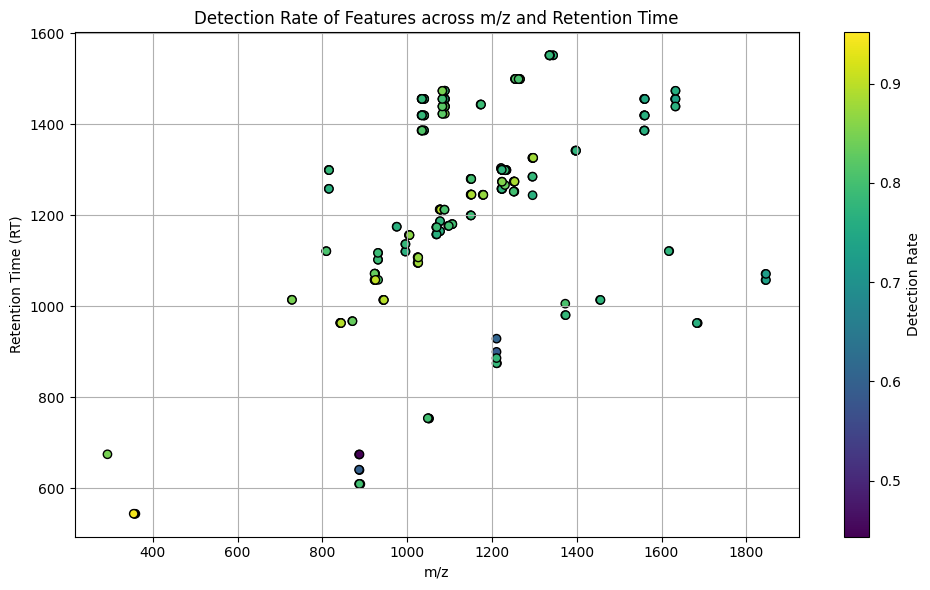

In [103]:
# Detection Rate for each Feature (How many samples have detected each feature)
detection_rate = (data_matrix > threshold).sum(axis=0) / len(data_matrix > threshold)

# Merge detection_rate with metadata
feature_info = feature_metadata.copy()
feature_info['detection_rate'] = detection_rate.values  # Make sure alignment is correct!

# Now scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(feature_info['mz'], feature_info['rt'], 
            c=feature_info['detection_rate'], cmap='viridis', edgecolor='k')

plt.colorbar(label='Detection Rate')
plt.xlabel('m/z')
plt.ylabel('Retention Time (RT)')
plt.title('Detection Rate of Features across m/z and Retention Time')
plt.grid(True)
plt.tight_layout()
plt.show()

### Contaminants

By taking a look at the features that are detected in blank samples, we notice there are 3 features that have high peak area values. Let's take a deeper look a deeper look at this.

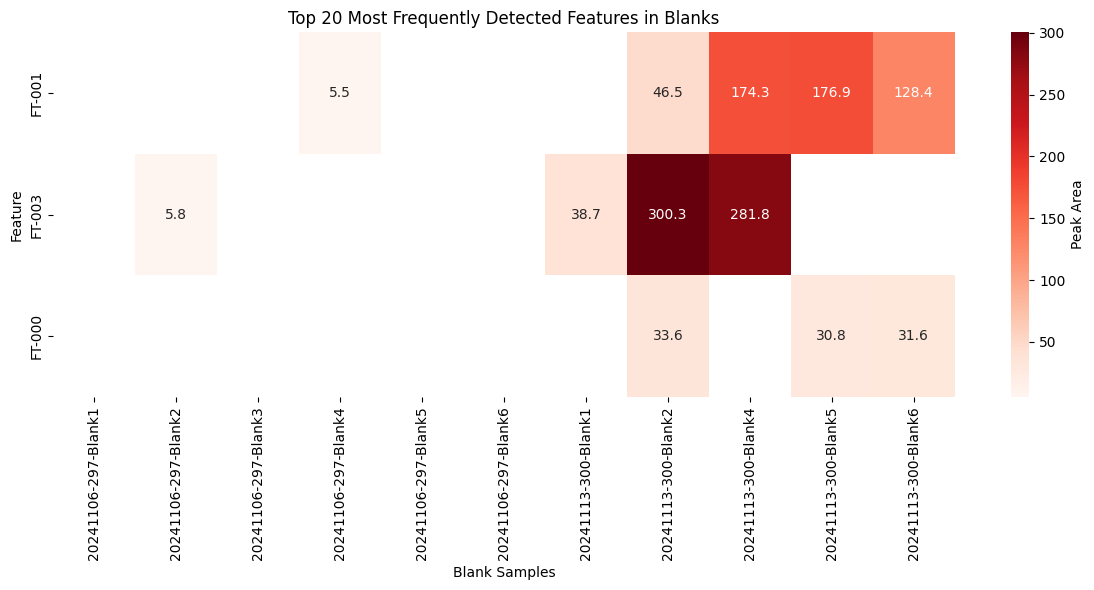

In [104]:
contaminated_features = 3

# Filter blank samples for detected features
detected_blanks = blanks[blanks>threshold]

# Count number of blanks each feature is detected
feature_counts = detected_blanks.count(axis=0).sort_values(ascending=False)

top_features = feature_counts.head(3).index  # Change number as needed
top_data = detected_blanks[top_features]

plt.figure(figsize=(12, 6))
sns.heatmap(top_data.T, cmap='Reds', cbar_kws={'label': 'Peak Area'}, annot=True, fmt='.1f')

plt.title('Top 20 Most Frequently Detected Features in Blanks')
plt.xlabel('Blank Samples')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Features FT-000, FT-003 and Ft-001 seem to be consistently detected in blank samples, in particular blank samples from batch 2. To further mitigate this effect, we could get rid of these features in further analysis, to avoid bias due to contamination.

### Exogenous Standards Detection Consistency

To investigate standard detection consistency, we need to identify the features that correspond to the exogenous standards in the SS samples. Since batch 2 does not contain any sample data, in the SS sample of batch 2, the detected features should only correspond to the exogenous standards. Let's take a look at this sample.

In [105]:
#standards_samples = data_matrix[(data_matrix_types['class'] == 'SS') & (data_matrix_types['batch'] == 2)]
standards_samples = data_matrix[(data_matrix_types['class'] == 'SS')]

standards_features = standards_samples[standards_samples>threshold].dropna(axis=1, how='all')

standards_metadata = feature_metadata.loc[feature_metadata.index.isin(standards_features.columns)]

In [106]:
tolerance = 10

std_labels = []
std_features = []
std_features_mapping = {}

for index_j, row_j in exogenous_stds.iterrows():
    std_features_mapping[index_j] = []
    std_mz = row_j['mz']
    std_rt = row_j['Retention_time']
    
    for index, row in standards_metadata.iterrows():
        ft_mz = row['mz']
        ft_rt = row['rt']  
        
        if (abs(std_mz - ft_mz) <= tolerance) or (abs(std_rt - ft_rt) <= tolerance):
            std_labels.append(index_j)
            std_features.append(index)
            std_features_mapping[index_j].append(index)

standards_metadata = standards_metadata.loc[standards_metadata.index.isin(std_features)]
standards_metadata['Standard'] = std_labels

Now that we have identified the features that corresponds to the exogenous standards, let's filter the data matrix to only keep the information about these features.

In [107]:
standards_data_matrix = data_matrix.copy()
standards_data_matrix = data_matrix.loc[:, data_matrix.columns.isin(standards_metadata.index)]

For quality control check, we want to check whether the standards (SS) are consistently detected across samples

#### Across Samples

We start by splitting the data matrix into 4 different ones: one for each standard.

In [108]:
def plot_standard_feature_trends(standard_name, std_features_mapping, standards_data_matrix, threshold=10):
    # Get feature names for the selected standard
    standard_features = std_features_mapping[standard_name]
    
    # Select relevant columns
    standard_data = standards_data_matrix.loc[:, standards_data_matrix.columns.isin(standard_features)]
    
    # Filter: only keep samples where all selected features are detected (above threshold)
    standard_data = standard_data[standard_data > threshold].dropna(axis=0)

    # x-axis: sample indices
    x = np.arange(len(standard_data)).reshape(-1, 1)

    # Line plot of feature values across samples
    plt.figure(figsize=(20, 6))
    for feature in standard_data.columns:
        plt.plot(x, standard_data[feature], label=feature)

    plt.xlabel('Sample Index')
    plt.ylabel('Peak Area')
    plt.title(f'Peak Area Evolution Across Samples for {standard_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Subplots with linear regression fits
    n_features = len(standard_data.columns)
    n_cols = 4
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axs = axs.flatten()

    for i, feature in enumerate(standard_data.columns):
        y = standard_data[feature].values
        mask = ~np.isnan(y)

        if np.sum(mask) < 2:
            axs[i].set_visible(False)
            continue

        model = LinearRegression()
        model.fit(x[mask], y[mask])
        y_pred = model.predict(x)

        axs[i].plot(x, y, label="Data", alpha=0.6)
        axs[i].plot(x, y_pred, label="Trend", linestyle='--')
        axs[i].set_title(feature)
        axs[i].set_xlabel('Sample Index')
        axs[i].set_ylabel('Peak Area')
        axs[i].legend()

    # Hide any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()


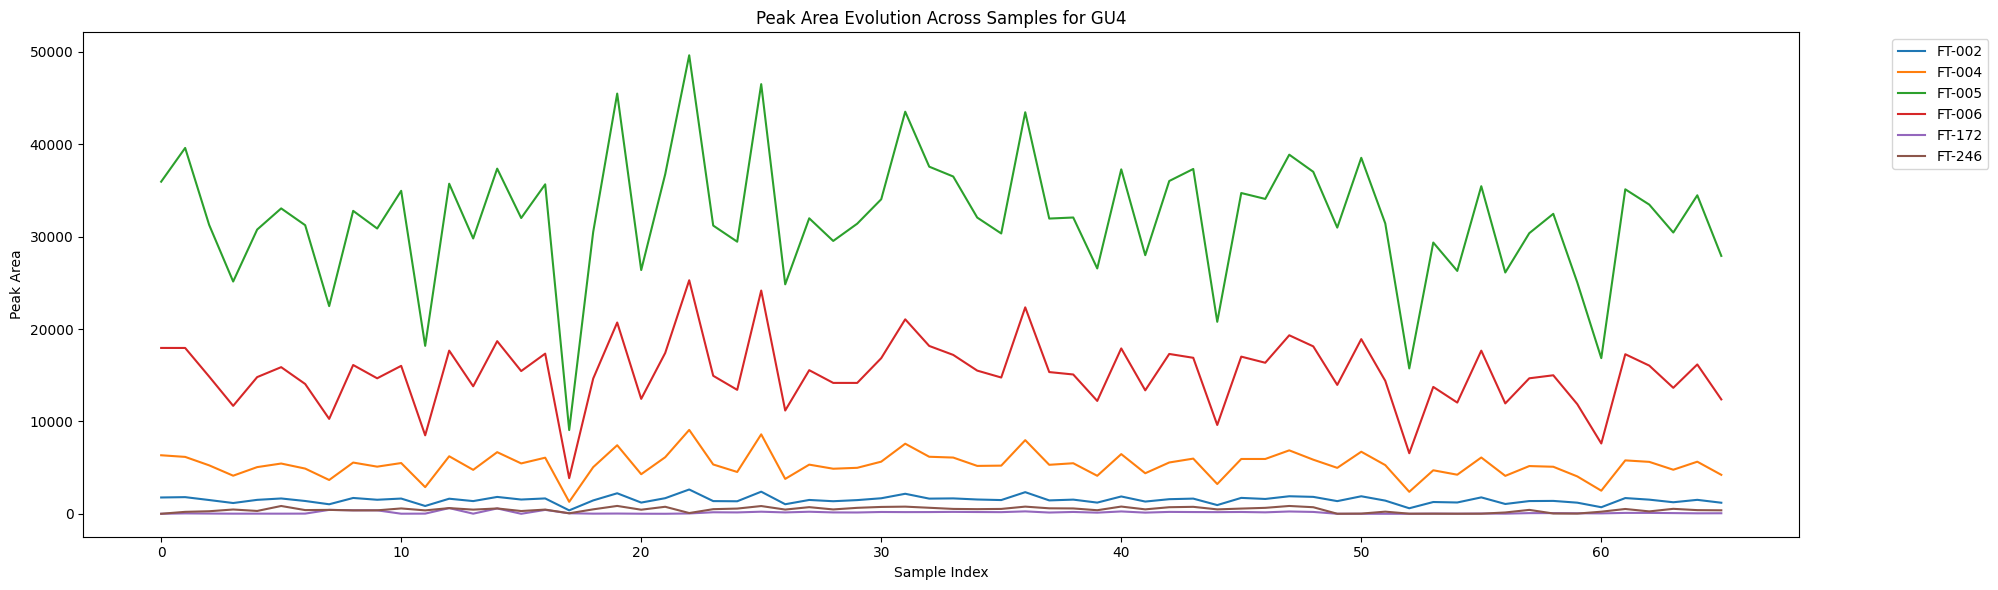

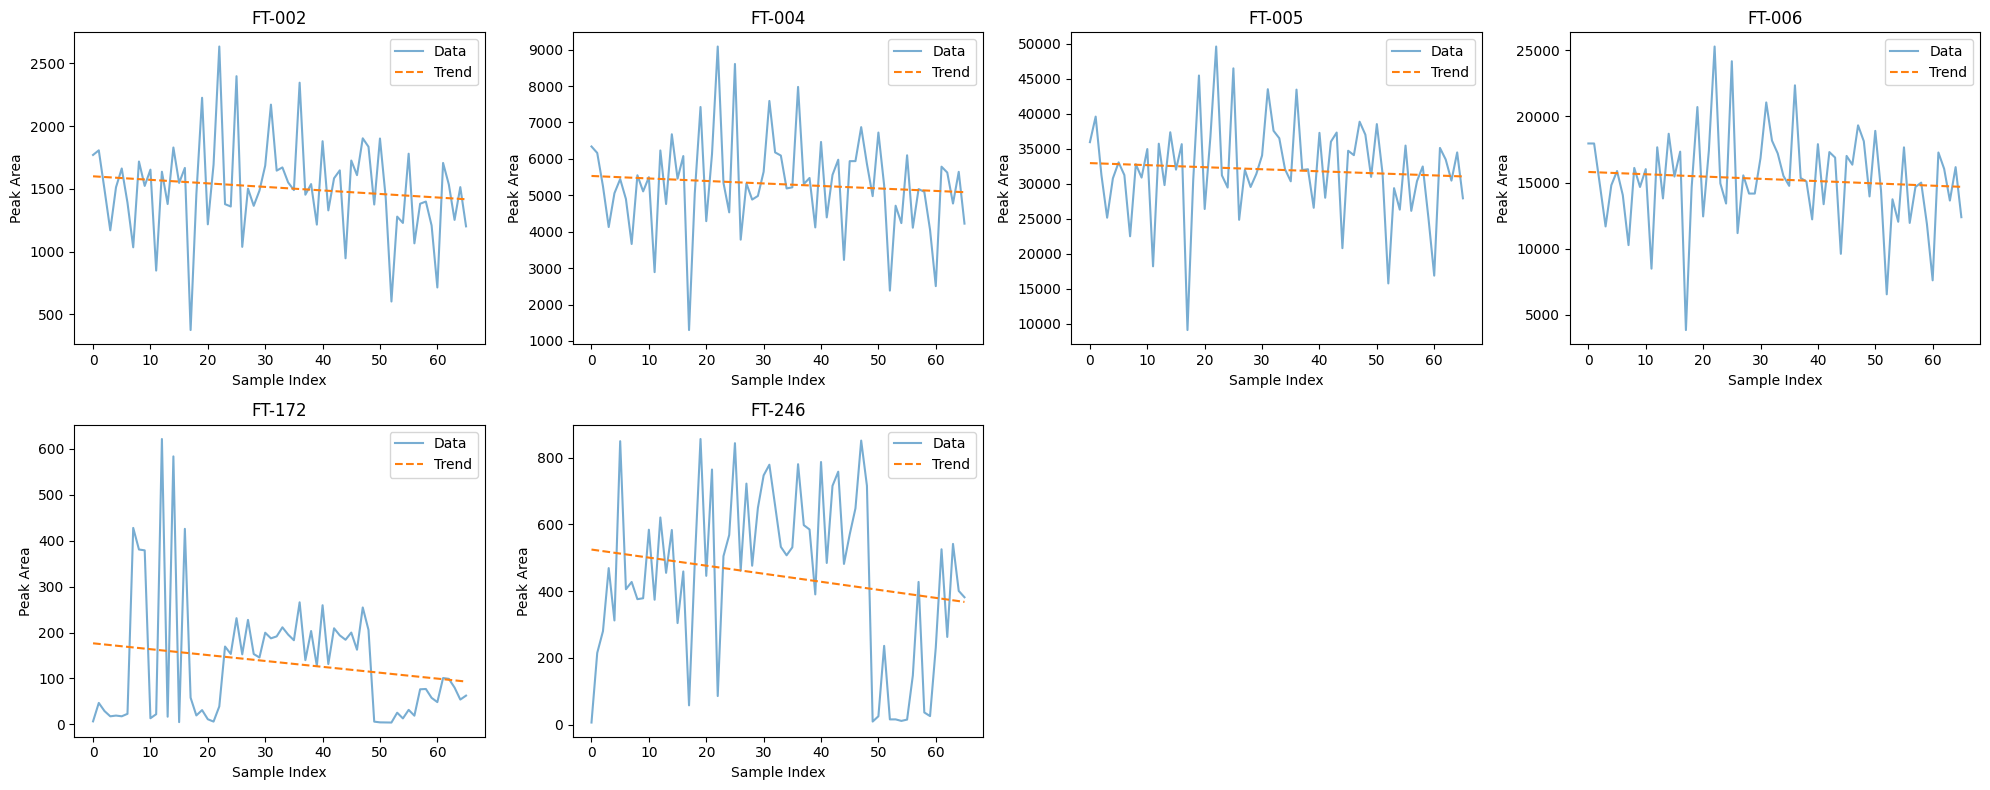

In [109]:
# GU4
plot_standard_feature_trends('GU4', std_features_mapping, standards_data_matrix, threshold)

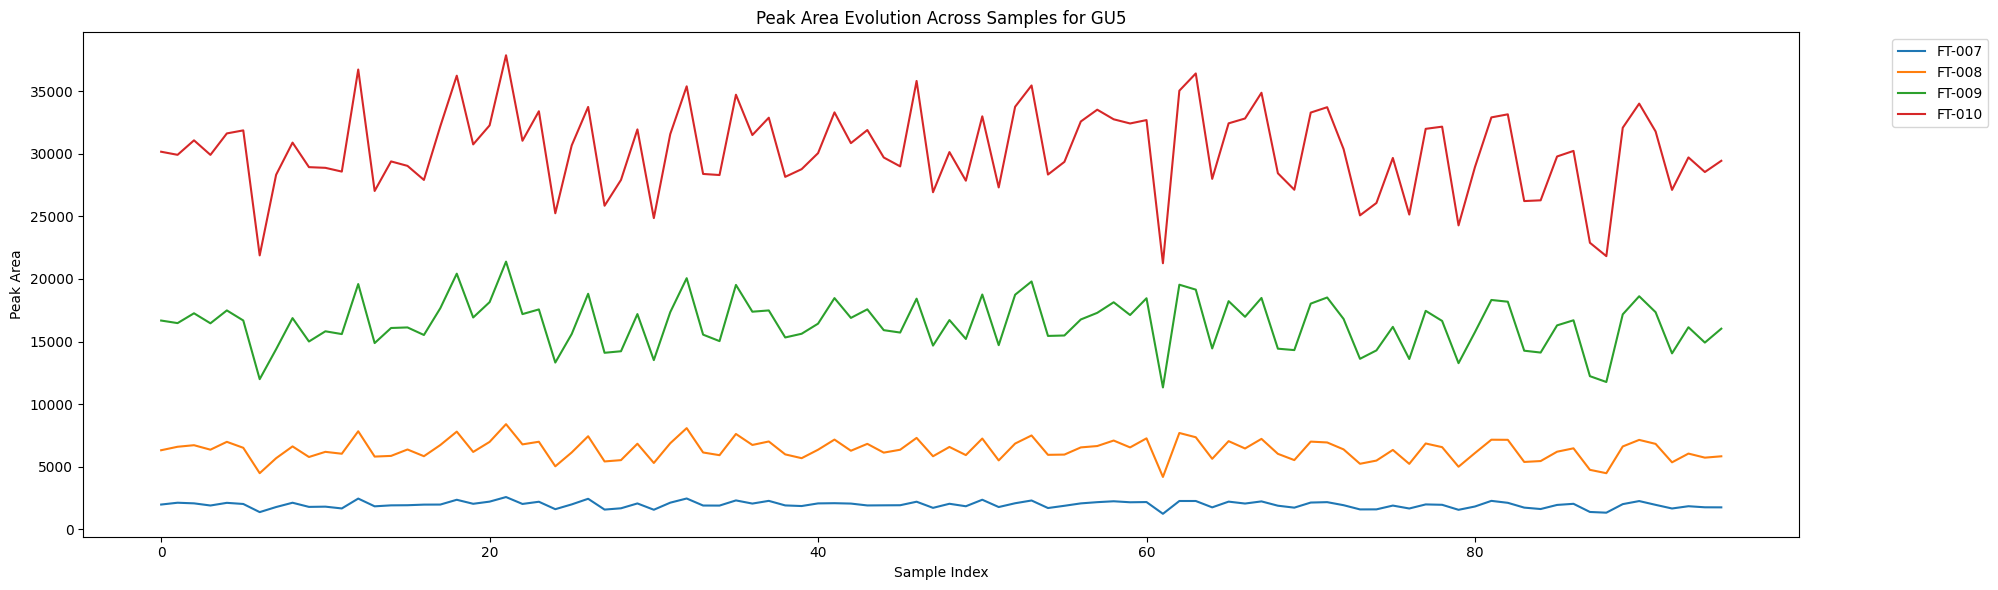

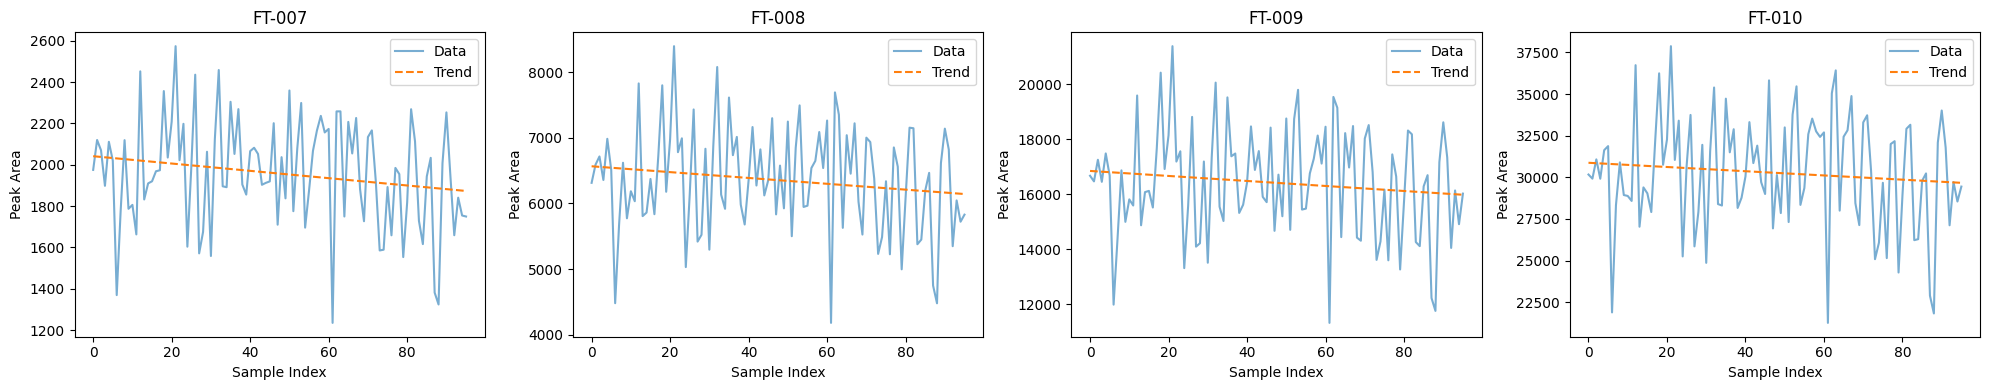

In [110]:
# GU5
# GU14
plot_standard_feature_trends('GU5', std_features_mapping, standards_data_matrix, threshold)

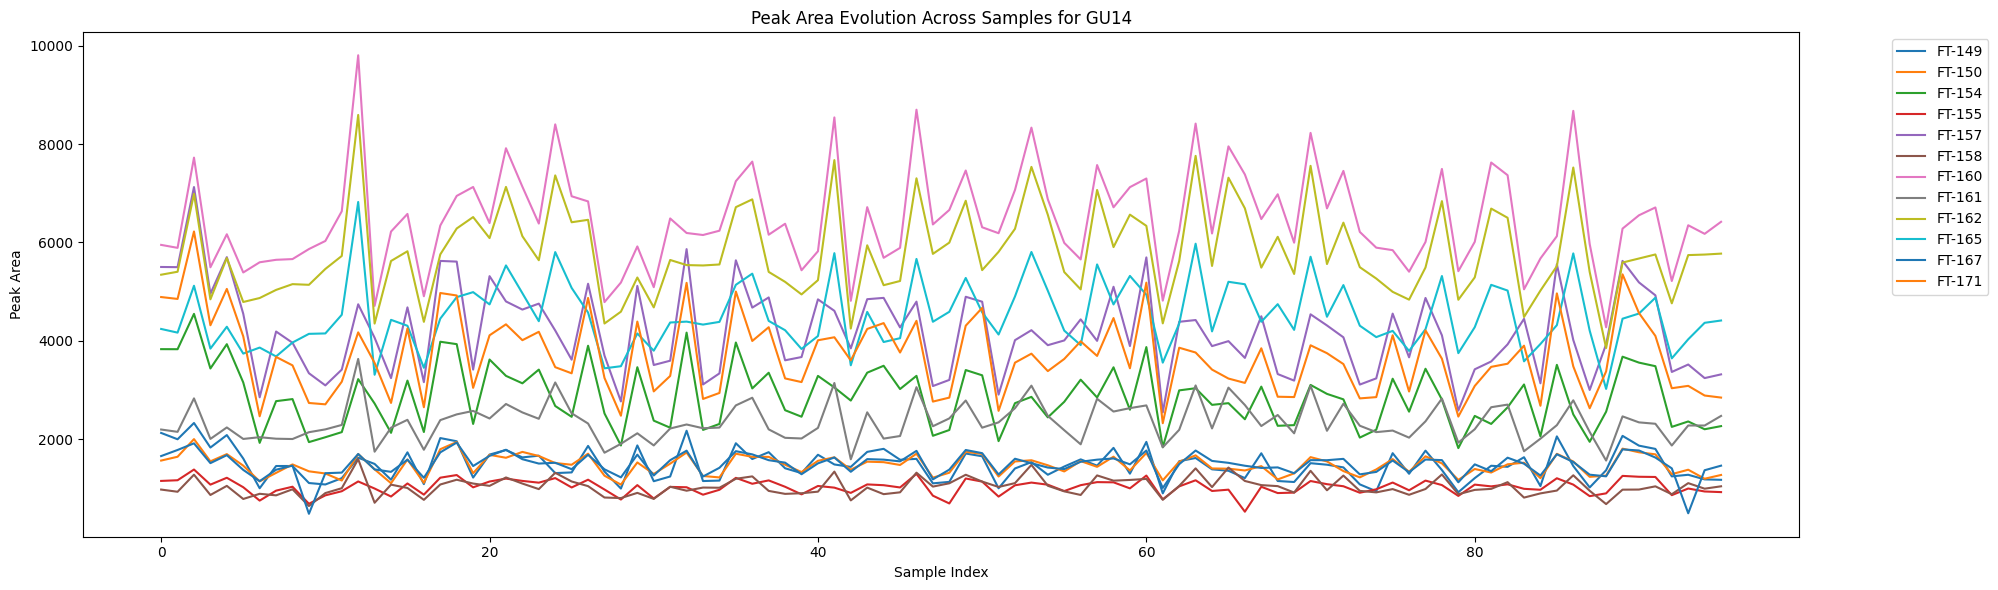

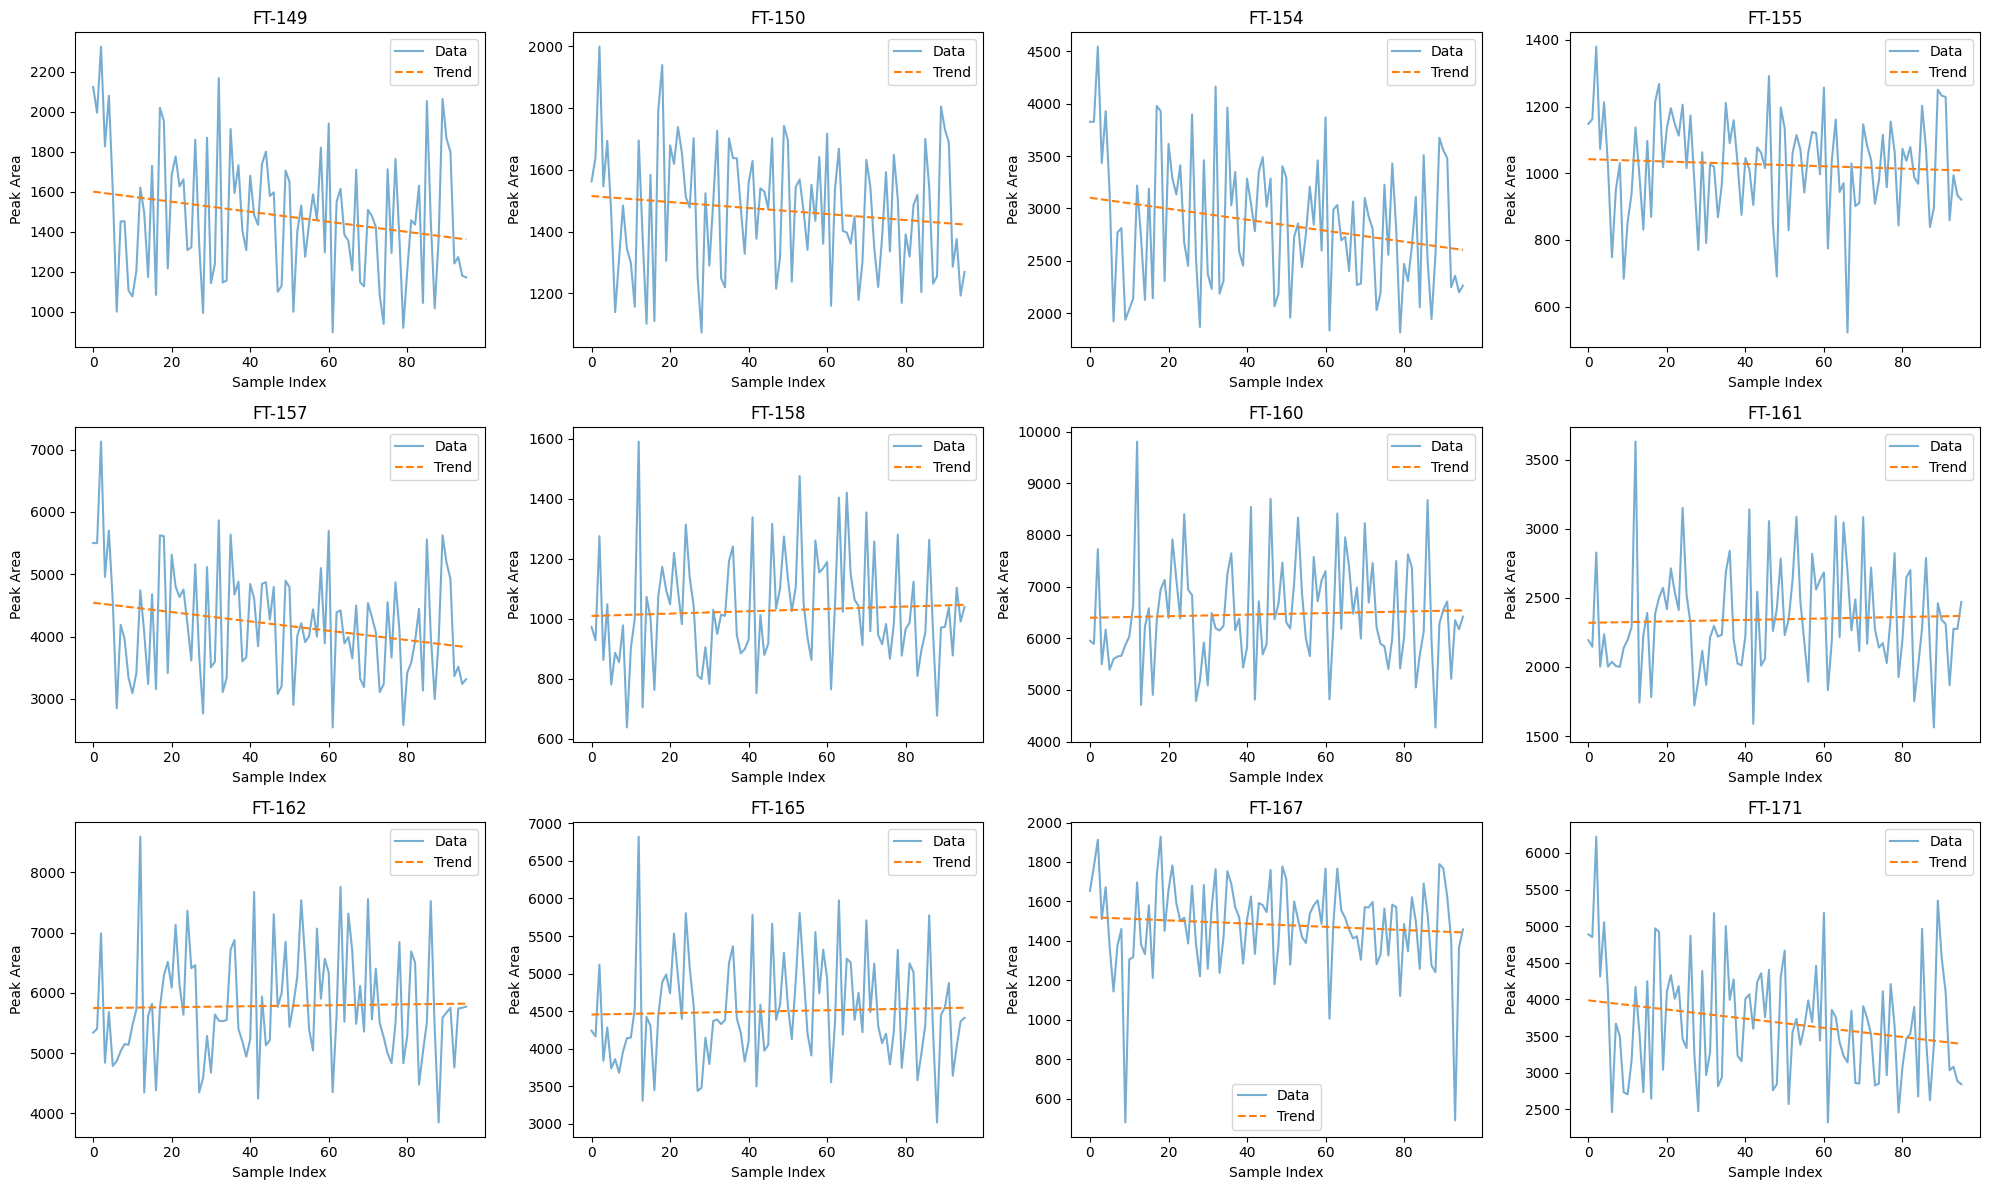

In [111]:
# GU14
plot_standard_feature_trends('GU14', std_features_mapping, standards_data_matrix, threshold)

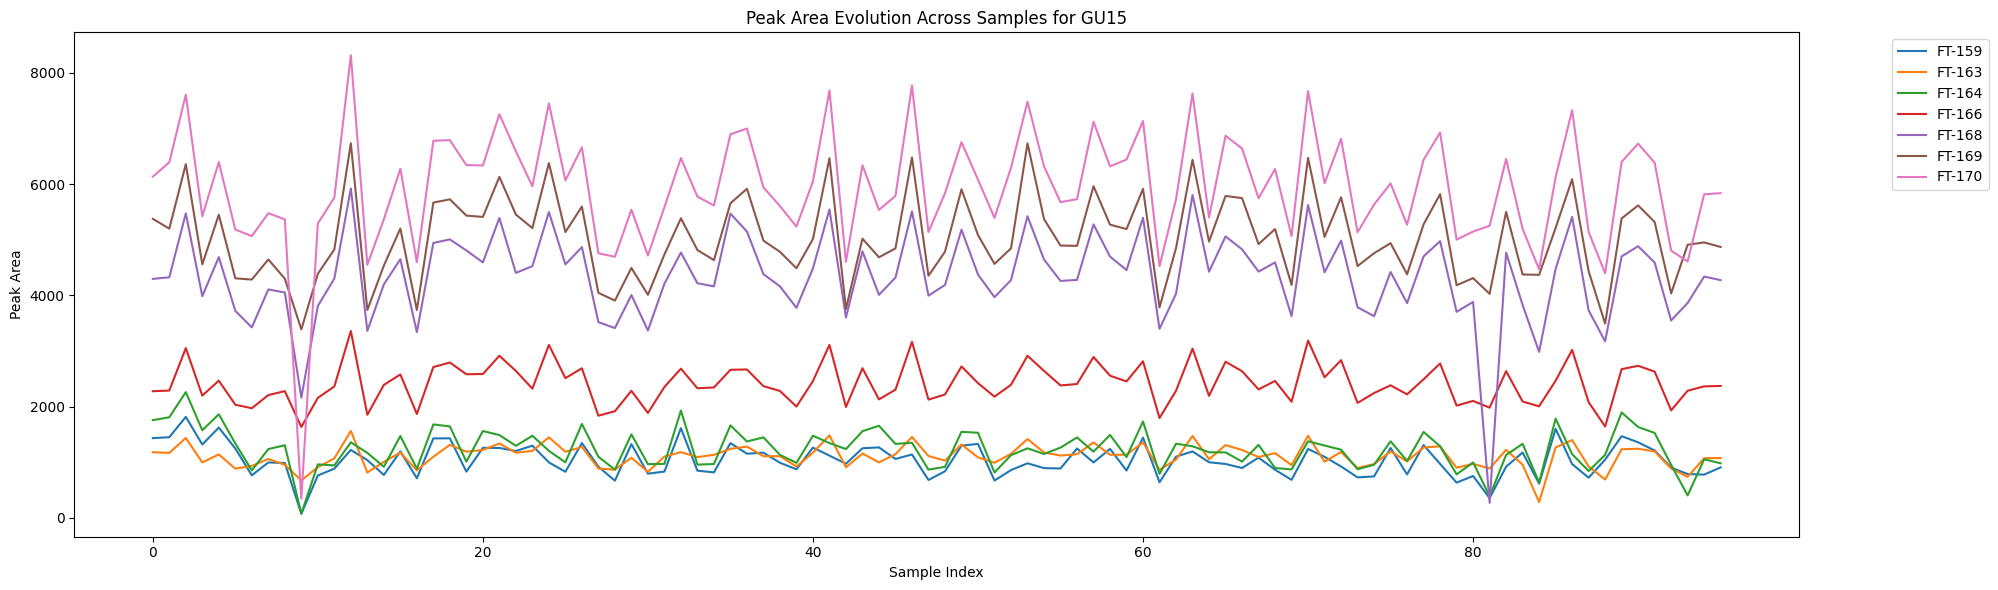

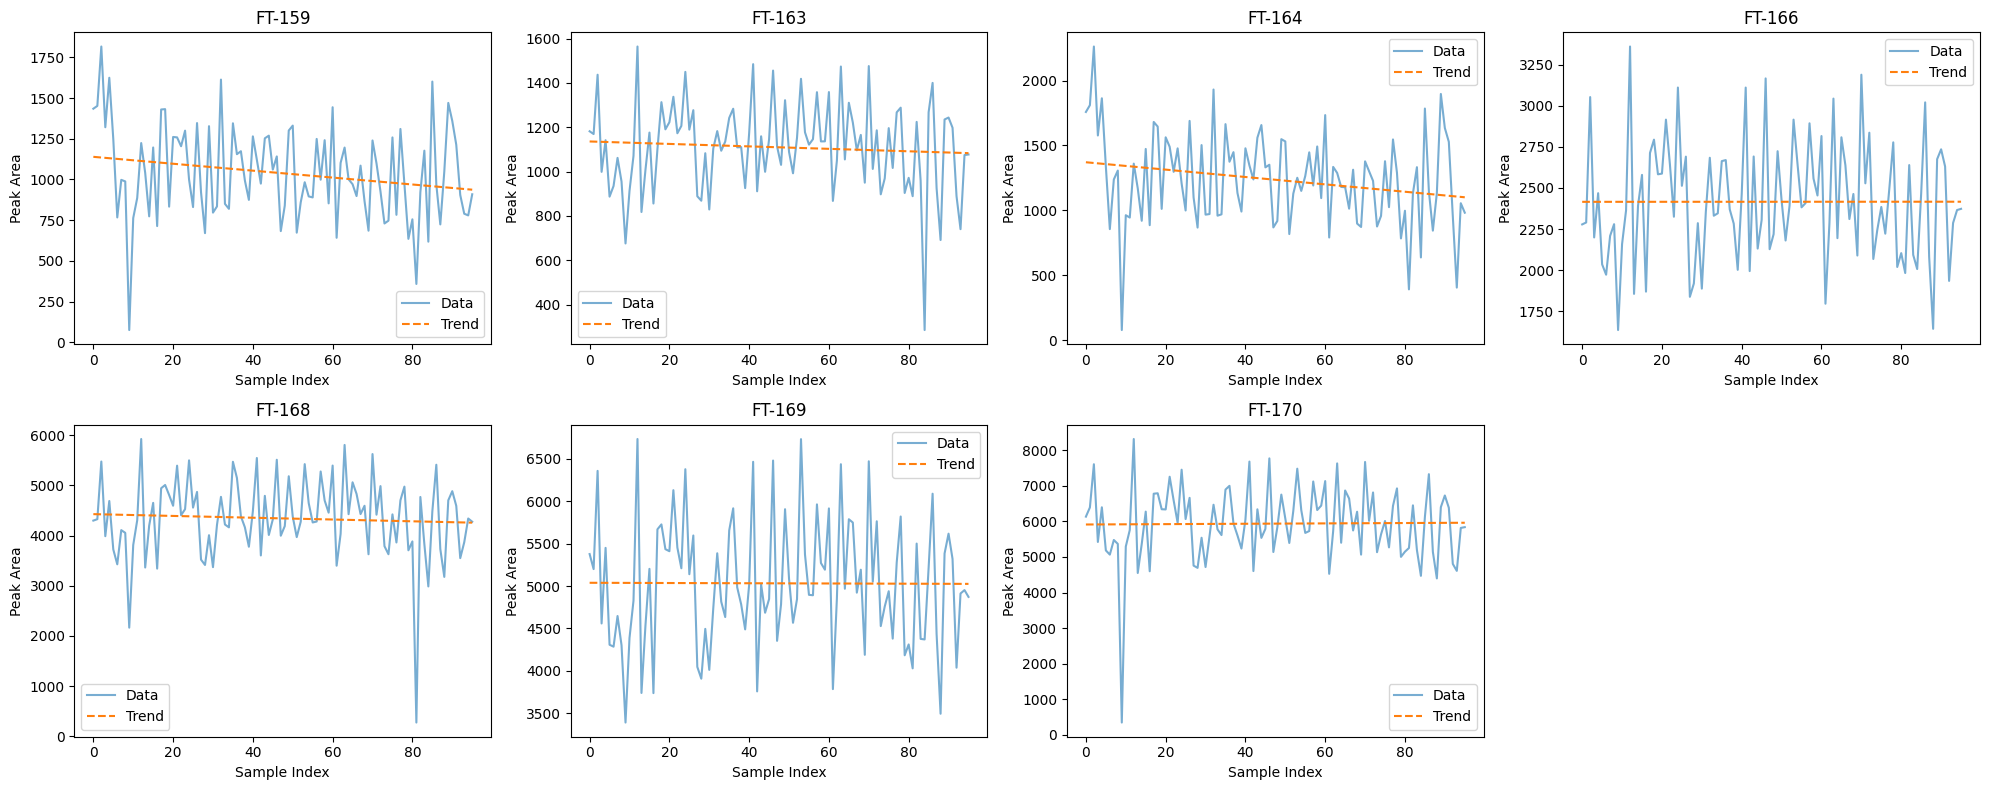

In [112]:
# GU15
plot_standard_feature_trends('GU15', std_features_mapping, standards_data_matrix, threshold)

### Distribution of Intensities across Classes

We would like to look at the distribution of peak area values across the classes, and to investigate any trends with respect to classes and run order.

<Figure size 800x600 with 0 Axes>

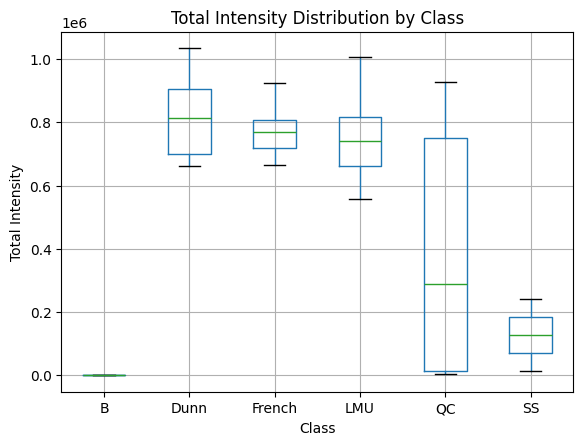

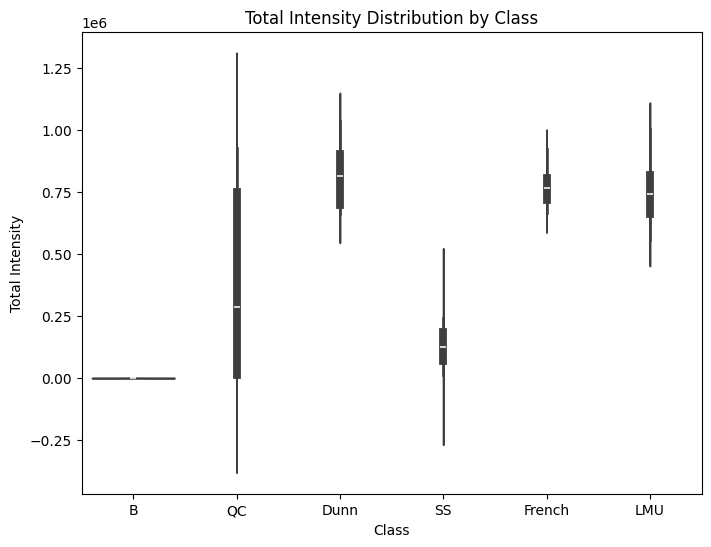

In [113]:
data_matrix_types['total_intensity'] = data_matrix.sum(axis=1)


plt.figure(figsize=(8, 6))
data_matrix_types.boxplot(column='total_intensity', by='class')
plt.title('Total Intensity Distribution by Class')
plt.suptitle('')  # Remove the automatic subtitle
plt.xlabel('Class')
plt.ylabel('Total Intensity')
plt.show()

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(x='class', y='total_intensity', data=data_matrix_types)
plt.title('Total Intensity Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Total Intensity')
plt.show()

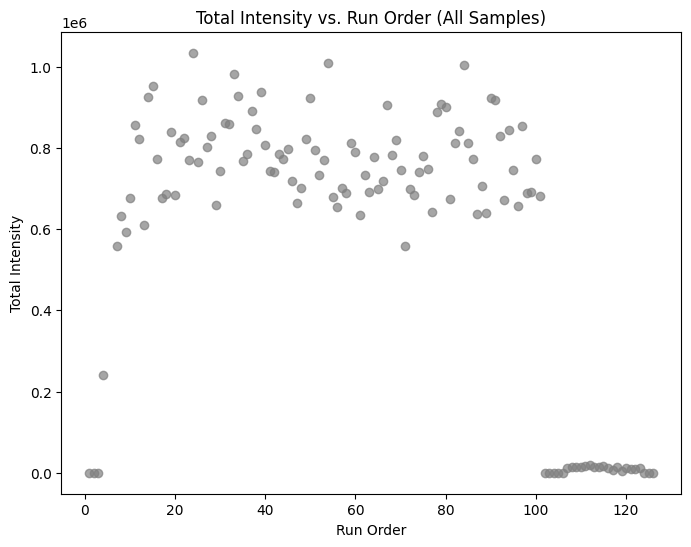

In [114]:
plt.figure(figsize=(8, 6))
plt.scatter(data_matrix_types['order'], data_matrix_types['total_intensity'], c='gray', alpha=0.7)
plt.xlabel('Run Order')
plt.ylabel('Total Intensity')
plt.title('Total Intensity vs. Run Order (All Samples)')
plt.show()

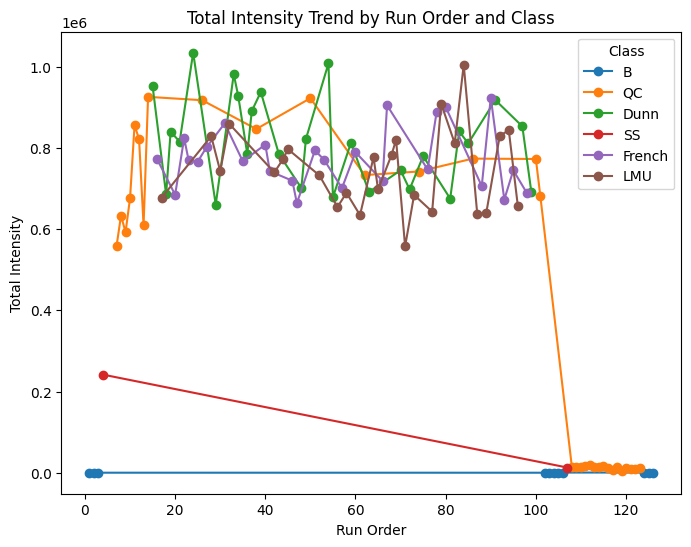

In [115]:
plt.figure(figsize=(8, 6))
for cls in data_matrix_types['class'].unique():
    subset = data_matrix_types[data_matrix_types['class'] == cls]
    # Sorting by run order for a smoother trend line
    subset = subset.sort_values('order')
    plt.plot(subset['order'], subset['total_intensity'], marker='o', linestyle='-', label=str(cls))
plt.xlabel('Run Order')
plt.ylabel('Total Intensity')
plt.title('Total Intensity Trend by Run Order and Class')
plt.legend(title='Class')
plt.show()


In [116]:
from scipy.stats import kruskal

groups = [group['total_intensity'].values for name, group in data_matrix_types.groupby('class')]
stat, p_value = kruskal(*groups)
print(f"Kruskal-Wallis test statistic: {stat}, p-value: {p_value}")


Kruskal-Wallis test statistic: 53.900598773090735, p-value: 2.196763278127315e-10


### Measurement Stability

In [117]:
qc_samples = data_matrix_types[data_matrix_types['class'] == 'QC']  # Adjust if necessary

# Assuming you're looking at one feature
cv = qc_samples['total_intensity'].std() / qc_samples['total_intensity'].mean() * 100
print('QC CV (%):', cv)

QC CV (%): 100.71797796930579


In [118]:
qc_samples = data_matrix_types[data_matrix_types['class'] == 'QC']  # Adjust if necessary

qc_samples = qc_samples.drop(['order', 'id', 'batch', 'class', 'total_intensity'], axis=1)
qc_samples = (qc_samples - qc_samples.mean())/qc_samples.std()

qc_samples['total_intensity'] = qc_samples.sum()

# Assuming you're looking at one feature
cv = qc_samples['total_intensity'].std() / qc_samples['total_intensity'].mean() * 100
print('QC CV (%):', cv)

QC CV (%): nan
